In [1]:
from __future__ import annotations

import math
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb


ENTITY = os.environ.get("WANDB_ENTITY")

if not ENTITY:
    raise RuntimeError(
        "WANDB_ENTITY is not set. Set it to your W&B entity name."
    )

PROJECT = "synthetic-1d-sawtooth-interpolation"

In [4]:
RUNS = {
    "Dropout 14–30, alpha=1": {
        "run_id": "sawtooth-dropout-fourier-nc14-30-v1",
        "alpha": 1.0,
    },
    "StochLN 14–30, alpha=1": {
        "run_id": "sawtooth-stochln-fourier-nc14-30-v1",
        "alpha": 1.0,
    },
    "Dropout 48–64, alpha=1": {
        "run_id": "sawtooth-dropout-fourier-nc48-64-v1",
        "alpha": 1.0,
    },
    "Dropout fixed 128, alpha=1": {
        "run_id": "sawtooth-fourier-dropout-nc128-v1",
        "alpha": 1.0,
    },
    "Dropout 14–30, alpha=0.05": {
        "run_id": "sawtooth-dropout-fourier-nc14-30-alpha005-v1",
        "alpha": 0.05,
    },

    "Dropout fixed 64, alpha=1": {
    "run_id": (
        "sawtooth-dropout-fourier-fixed-nc64-v1"
    ),
    "alpha": 1.0,
    },
    
    "Dropout fixed 96, alpha=1": {
        "run_id": (
            "sawtooth-dropout-fourier-fixed-nc96-v1"
        ),
        "alpha": 1.0,
    },
    
    "StochLN fixed 128, alpha=1": {
        "run_id": (
            "sawtooth-stochln-fourier-nc128-v1"
        ),
        "alpha": 1.0,
    },
}

OUTPUT_DIR = Path(
    "results/sawtooth/context_ladder_convergence"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RMSE_ESCAPE_THRESHOLD = 0.25
CRPS_ESCAPE_THRESHOLD = 0.160
SUSTAINED_CHECKS = 5

In [5]:
def fetch_history(
    run: wandb.apis.public.Run,
    metric: str,
) -> pd.DataFrame:
    frame = run.history(
        samples=10_000,
        keys=[metric, "epoch"],
        x_axis="trainer/global_step",
        pandas=True,
    )

    required = {
        "trainer/global_step",
        metric,
    }

    missing = required.difference(frame.columns)

    if missing:
        raise RuntimeError(
            f"Run {run.name!r} is missing {sorted(missing)}. "
            f"Available columns: {list(frame.columns)}"
        )

    keep = [
        "trainer/global_step",
        metric,
    ]

    if "epoch" in frame.columns:
        keep.append("epoch")

    frame = frame[keep].copy()

    frame["trainer/global_step"] = pd.to_numeric(
        frame["trainer/global_step"],
        errors="coerce",
    )

    frame[metric] = pd.to_numeric(
        frame[metric],
        errors="coerce",
    )

    frame = (
        frame
        .dropna(
            subset=[
                "trainer/global_step",
                metric,
            ]
        )
        .sort_values(
            "trainer/global_step",
            kind="stable",
        )
        .drop_duplicates(
            subset=["trainer/global_step"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    frame["validation_index"] = np.arange(
        len(frame)
    )

    if (
        "epoch" in frame.columns
        and pd.to_numeric(
            frame["epoch"],
            errors="coerce",
        ).notna().any()
    ):
        frame["epoch_resolved"] = (
            pd.to_numeric(
                frame["epoch"],
                errors="coerce",
            )
            .ffill()
            .bfill()
        )
    else:
        # Validation was run once per epoch.
        frame["epoch_resolved"] = (
            frame["validation_index"]
        )

    return frame


def first_sustained_below(
    frame: pd.DataFrame,
    *,
    metric: str,
    threshold: float,
    window: int,
) -> int | None:
    below = (
        frame[metric] < float(threshold)
    )

    sustained = (
        below.astype(int)
        .rolling(window)
        .sum()
        .eq(window)
    )

    hit_indices = np.flatnonzero(
        sustained.to_numpy()
    )

    if len(hit_indices) == 0:
        return None

    start_index = int(
        hit_indices[0] - window + 1
    )

    return int(
        round(
            float(
                frame.loc[
                    start_index,
                    "epoch_resolved",
                ]
            )
        )
    )


api = wandb.Api(timeout=60)

all_project_runs = list(
    api.runs(f"{ENTITY}/{PROJECT}")
)

summary_rows: list[dict[str, Any]] = []
rmse_histories: dict[str, pd.DataFrame] = {}
crps_histories: dict[str, pd.DataFrame] = {}

for label, info in RUNS.items():
    run_id = info["run_id"]
    alpha = float(info["alpha"])

    matches = [
        run
        for run in all_project_runs
        if run.name.endswith(run_id)
    ]

    if len(matches) != 1:
        print(f"\nMatches for {label!r}, run ID {run_id!r}:")

        for run in matches:
            print(f"  {run.name} ({run.id})")

        raise RuntimeError(
            f"Expected exactly one matching run, found {len(matches)}."
        )

    run = matches[0]

    rmse = fetch_history(
        run,
        "val/rmse",
    )

    crps = fetch_history(
        run,
        "val/crps",
    )

    rmse_histories[label] = rmse
    crps_histories[label] = crps

    rmse_best_index = rmse["val/rmse"].idxmin()
    crps_best_index = crps["val/crps"].idxmin()

    rmse_escape_epoch = first_sustained_below(
        rmse,
        metric="val/rmse",
        threshold=RMSE_ESCAPE_THRESHOLD,
        window=SUSTAINED_CHECKS,
    )

    # The 0.160 threshold is only directly meaningful for the
    # alpha=1 fair-CRPS runs.
    crps_escape_epoch = (
        first_sustained_below(
            crps,
            metric="val/crps",
            threshold=CRPS_ESCAPE_THRESHOLD,
            window=SUSTAINED_CHECKS,
        )
        if math.isclose(alpha, 1.0)
        else None
    )

    summary_rows.append(
        {
            "model": label,
            "wandb_run_name": run.name,
            "alpha": alpha,
            "num_validation_points": len(rmse),
            "rmse_escape_epoch": rmse_escape_epoch,
            "minimum_val_rmse": float(
                rmse.loc[
                    rmse_best_index,
                    "val/rmse",
                ]
            ),
            "epoch_of_minimum_rmse": int(
                round(
                    float(
                        rmse.loc[
                            rmse_best_index,
                            "epoch_resolved",
                        ]
                    )
                )
            ),
            "final_val_rmse": float(
                rmse["val/rmse"].iloc[-1]
            ),
            "crps_escape_epoch_alpha1_only": (
                crps_escape_epoch
            ),
            "minimum_val_crps": float(
                crps.loc[
                    crps_best_index,
                    "val/crps",
                ]
            ),
            "epoch_of_minimum_crps": int(
                round(
                    float(
                        crps.loc[
                            crps_best_index,
                            "epoch_resolved",
                        ]
                    )
                )
            ),
            "final_val_crps": float(
                crps["val/crps"].iloc[-1]
            ),
        }
    )

In [6]:
summary = pd.DataFrame(summary_rows)

summary_path = (
    OUTPUT_DIR
    / "sawtooth_context_ladder_convergence.csv"
)

summary.to_csv(
    summary_path,
    index=False,
)

display(summary)

print(f"Saved: {summary_path}")

,model,wandb_run_name,alpha,num_validation_points,rmse_escape_epoch,minimum_val_rmse,epoch_of_minimum_rmse,final_val_rmse,crps_escape_epoch_alpha1_only,minimum_val_crps,epoch_of_minimum_crps,final_val_crps
0,"Dropout 14–30, alpha=1",sawtooth-dropout-fourier-nc14-30-sawtooth-drop...,1.00,500,NaN,0.301132,254,0.302443,NaN,0.166274,426,0.166485
1,"StochLN 14–30, alpha=1",sawtooth-stochln-fourier-nc14-30-sawtooth-stoc...,1.00,500,NaN,0.299656,92,0.302656,NaN,0.166036,411,0.166583
2,"Dropout 48–64, alpha=1",sawtooth-dropout-fourier-nc48-64-sawtooth-drop...,1.00,500,NaN,0.300953,58,0.302431,NaN,0.166295,303,0.166409
3,"Dropout fixed 128, alpha=1",sawtooth-fourier-dropout-nc128-sawtooth-fourie...,1.00,500,85.0,0.062343,497,0.062611,71.0,0.007622,497,0.007650
4,"Dropout 14–30, alpha=0.05",sawtooth-dropout-fourier-nc14-30-alpha005-sawt...,0.05,500,NaN,0.295688,99,0.296710,NaN,0.182352,17,0.183353
5,"Dropout fixed 64, alpha=1",sawtooth-dropout-fourier-fixed-nc64-sawtooth-d...,1.00,500,164.0,0.076771,486,0.076891,122.0,0.011598,486,0.011613
6,"Dropout fixed 96, alpha=1",sawtooth-dropout-fourier-fixed-nc96-sawtooth-d...,1.00,500,100.0,0.068126,494,0.068276,74.0,0.009071,494,0.009090
7,"StochLN fixed 128, alpha=1",sawtooth-stochln-fourier-nc128-sawtooth-stochl...,1.00,500,NaN,0.300083,3,0.303301,NaN,0.165808,497,0.166737


Saved: results/sawtooth/context_ladder_convergence/sawtooth_context_ladder_convergence.csv


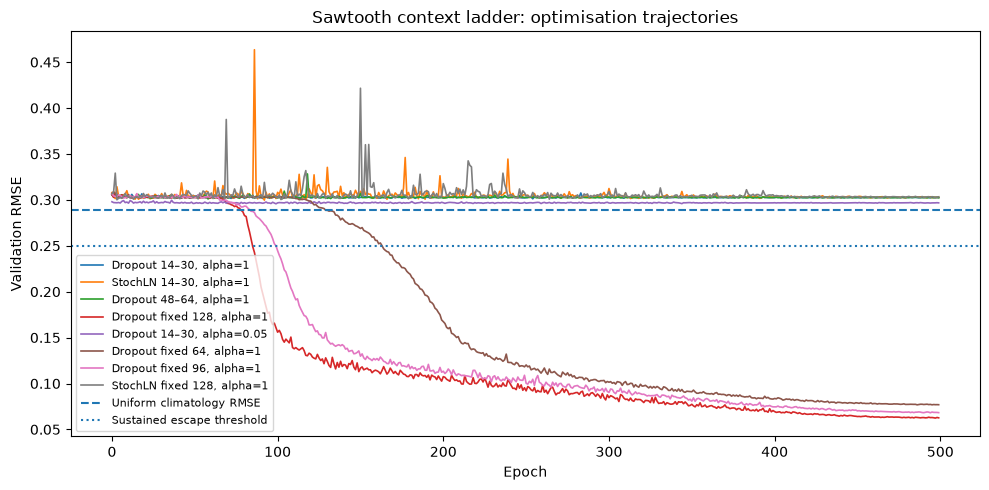

Saved: results/sawtooth/context_ladder_convergence/sawtooth_context_ladder_val_rmse.pdf


In [7]:
plt.figure(figsize=(10, 5))

for label, frame in rmse_histories.items():
    plt.plot(
        frame["epoch_resolved"],
        frame["val/rmse"],
        label=label,
        linewidth=1.2,
    )

plt.axhline(
    math.sqrt(1.0 / 12.0),
    linestyle="--",
    label="Uniform climatology RMSE",
)

plt.axhline(
    RMSE_ESCAPE_THRESHOLD,
    linestyle=":",
    label="Sustained escape threshold",
)

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Sawtooth context ladder: optimisation trajectories")
plt.legend(fontsize=8)
plt.tight_layout()

path = (
    OUTPUT_DIR
    / "sawtooth_context_ladder_val_rmse.pdf"
)

plt.savefig(
    path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {path}")